# MCDIA503 · Exploración Inteligente para la Ciencia de Datos
## Evaluación Sumativa 2 · Avance del proyecto Fases 2 y 3
### I. Encabezado e identificación del notebook
**Integrantes:** Luis Díaz · Gonzalo Bouldres · Eduardo Contreras  
**Grupo:** 6 · **Curso:** 202681.2538 · **Profesor:** Sergio Paraíso  
**Fecha:** 17/09/2026 · **Dataset:** Titanic, copia local de Seaborn.

**Foco:** ¿qué diferencias descriptivas de supervivencia se observan según sexo, clase, edad, tarifa y composición familiar? El objetivo es preparar una base consistente y trazable y explorar patrones iniciales, sin estimar efectos causales ni construir modelos predictivos. Titanic permite evidenciar faltantes, redundancias, extremos e integración mediante tablas derivadas, modalidad admitida en las instrucciones de Sumativa 2 (Universidad Andrés Bello, 2026).

**Reproducibilidad:** descomprimir el proyecto completo, instalar `requirements.txt` y abrir este archivo desde Jupyter. Ejecutar **Kernel → Restart Kernel and Run All Cells**. La entrada incluida está en `data/input/titanic.csv`; no se requiere red para ejecutar. El informe usa exclusivamente las cifras, interpretaciones y figuras exportadas por este notebook. Las advertencias no se ocultan.

## II. Carga del dataset y descripción inicial
Se importa el entorno, se localiza la raíz y se valida el esquema de 15 campos. El CSV proviene del repositorio de datos de Seaborn (Waskom, s. f.); no se convierte otro esquema de Titanic. El SHA-256 permite detectar cambios en la entrada.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220, "axes.titleweight": "bold"})
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents]
                     if (p / "data/input/titanic.csv").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Abra el notebook dentro del proyecto que contiene data/input/titanic.csv")
INPUT_DIR = PROJECT_ROOT / "data/input"
PROCESS_DIR = PROJECT_ROOT / "data/process"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
for folder in [PROCESS_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
DATA_PATH = INPUT_DIR / "titanic.csv"
sha = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
titanic = pd.read_csv(DATA_PATH)
expected = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
            'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
assert list(titanic.columns) == expected, "Se requiere el esquema original de Seaborn, sin conversiones."
assert titanic.shape == (891, 15), "La entrada no corresponde a la versión analizada."
original = titanic.copy(deep=True)
print("Entrada:", DATA_PATH.relative_to(PROJECT_ROOT))
print("SHA-256:", sha)
print("Dimensiones:", titanic.shape)
display(titanic.head())

# Las interpretaciones exportadas serán la fuente textual del informe.
interpretations = {}
def narrate(key, text):
    interpretations[key] = text
    display(Markdown(text))
def es(value, decimals=1):
    return f"{value:.{decimals}f}".replace(".", ",")
figures_created = []
def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / name, bbox_inches="tight")
    figures_created.append(name)
    plt.show()
    plt.close(fig)

Entrada: data/input/titanic.csv
SHA-256: 81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86ef4d4a76dc91b7d4f2
Dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## III. Revisión del contenido del dataset
Cada fila representa un pasajero del subconjunto distribuido, no la totalidad de personas a bordo. Se inspeccionan tipos, categorías y cardinalidad. `survived` es el resultado; `sex`, `pclass`, `age`, `fare`, `sibsp` y `parch` son las variables analíticas prioritarias. `class/pclass` y `alive/survived` contienen información redundante. La ausencia de un identificador de pasajero impide demostrar que dos perfiles iguales sean la misma persona.

In [2]:
review = pd.DataFrame({
    'tipo': titanic.dtypes.astype(str),
    'n_unicos': titanic.nunique(dropna=True),
    'n_missing': titanic.isna().sum(),
    'pct_missing': titanic.isna().mean().mul(100).round(2)
})
display(review)
review.to_csv(OUTPUTS_DIR / 'revision_estructura.csv')
for col in ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'deck', 'alive', 'alone']:
    print(col, titanic[col].dropna().unique().tolist())

survived [0, 1]
pclass [3, 1, 2]
sex ['male', 'female']
embarked ['S', 'C', 'Q']
class ['Third', 'First', 'Second']
who ['man', 'woman', 'child']
deck ['C', 'E', 'G', 'D', 'A', 'B', 'F']
alive ['no', 'yes']
alone [False, True]


,tipo,n_unicos,n_missing,pct_missing
survived,int64,2,0,0.00
pclass,int64,3,0,0.00
sex,object,2,0,0.00
age,float64,88,177,19.87
sibsp,int64,7,0,0.00
parch,int64,7,0,0.00
fare,float64,248,0,0.00
embarked,object,3,2,0.22
class,object,3,0,0.00
who,object,3,0,0.00


## IV. Diagnóstico de calidad de datos
Se aplica la lógica campo → regla → test → acción, con prioridad según impacto (Paraíso, 2026b). Alta: edad, identidad y consistencia de variables usadas en el foco; media: cubierta, embarque y extremos que requieren revisión. Los conteos se calculan; no se escriben manualmente.

En `who`, Seaborn clasifica como `child` las edades observadas menores de 16 años; en el resto conserva `man/woman` según sexo, incluso cuando la edad falta. Comprobar esta codificación no demuestra la edad real de esos casos.

,n_missing,pct_missing
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


,test,incumplimientos,cumple
0,survived_en_0_1,0,True
1,pclass_en_1_2_3,0,True
2,sex_valido,0,True
3,edad_entre_0_y_120_o_missing,0,True
4,fare_finita_no_negativa,0,True
5,sibsp_entero_no_negativo,0,True
6,parch_entero_no_negativo,0,True
7,embarked_valido_o_missing,0,True
8,deck_valido_o_missing,0,True
9,class_coherente_pclass,0,True


,campo,regla,test,diagnostico,prioridad,accion
0,age,Completitud,isna().sum(),"177 (19,9%)",Alta,Mediana por sexo y clase; variable nueva y ban...
1,deck,Completitud,isna().sum(),"688 (77,2%)",Media,Unknown y bandera; no inferir cubierta
2,embarked,Completitud,isna().sum(),"2 (0,2%)",Media,Moda; reconstruir ciudad en variable nueva
3,filas,Unicidad,duplicated().sum(),107 repeticiones adicionales,Alta,Conservar: sin ID no prueban duplicación real
4,variables relacionadas,Consistencia,checks entre campos,0 incumplimientos,Alta,Sin correcciones; validar tras preparar
5,age / fare,Plausibilidad,IQR y reglas de rango,Ver sección IX,Media,Marcar e investigar; no eliminar por distancia...


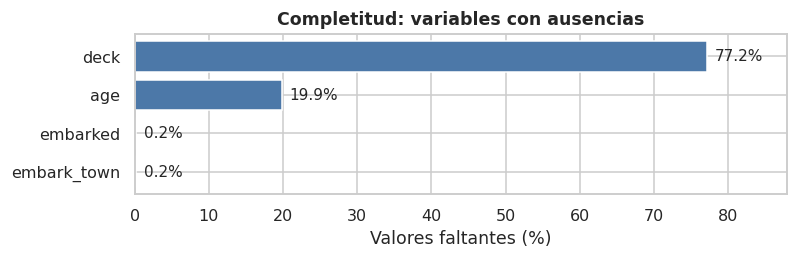

Hay 177 edades ausentes (19,9%), 688 cubiertas ausentes (77,2%) y 2 ausencias en cada campo de embarque. Se detectan 107 repeticiones adicionales de perfiles completos (12,0%), con 160 filas involucradas contando todas las ocurrencias. No se eliminan: sin ID único, la igualdad de atributos no demuestra identidad. Los 15 controles de validez y consistencia no presentan incumplimientos; esto no descarta errores no observables.

In [3]:
missing = review[['n_missing', 'pct_missing']].sort_values('pct_missing', ascending=False)
dups = int(titanic.duplicated().sum())
repeated_all = int(titanic.duplicated(keep=False).sum())
expected_who = pd.Series(np.where(titanic.age.lt(16), 'child',
                         np.where(titanic.sex.eq('male'), 'man', 'woman')), index=titanic.index)
checks = {
    'survived_en_0_1': titanic.survived.isin([0, 1]),
    'pclass_en_1_2_3': titanic.pclass.isin([1, 2, 3]),
    'sex_valido': titanic.sex.isin(['male', 'female']),
    'edad_entre_0_y_120_o_missing': titanic.age.isna() | titanic.age.between(0, 120),
    'fare_finita_no_negativa': np.isfinite(titanic.fare) & titanic.fare.ge(0),
    'sibsp_entero_no_negativo': titanic.sibsp.ge(0) & titanic.sibsp.mod(1).eq(0),
    'parch_entero_no_negativo': titanic.parch.ge(0) & titanic.parch.mod(1).eq(0),
    'embarked_valido_o_missing': titanic.embarked.isna() | titanic.embarked.isin(['C', 'Q', 'S']),
    'deck_valido_o_missing': titanic.deck.isna() | titanic.deck.isin(list('ABCDEFG')),
    'class_coherente_pclass': titanic['class'].eq(titanic.pclass.map({1:'First', 2:'Second', 3:'Third'})),
    'alive_coherente_survived': titanic.alive.eq(titanic.survived.map({0:'no', 1:'yes'})),
    'embark_town_coherente': titanic.embark_town.fillna('<NA>').eq(
        titanic.embarked.map({'C':'Cherbourg', 'Q':'Queenstown', 'S':'Southampton'}).fillna('<NA>')),
    'alone_coherente': titanic.alone.eq((titanic.sibsp + titanic.parch).eq(0)),
    'who_coherente_edad_sexo': titanic.who.eq(expected_who),
    'adult_male_coherente_who': titanic.adult_male.eq(titanic.who.eq('man'))
}
check_table = pd.DataFrame([{'test': k, 'incumplimientos': int((~v).sum()),
                            'cumple': bool(v.all())} for k, v in checks.items()])
display(missing)
display(check_table)
assert check_table.cumple.all(), "Revisar inconsistencias antes de continuar."
rows = []
for col, priority, action in [
    ('age', 'Alta', 'Mediana por sexo y clase; variable nueva y bandera'),
    ('deck', 'Media', 'Unknown y bandera; no inferir cubierta'),
    ('embarked', 'Media', 'Moda; reconstruir ciudad en variable nueva')]:
    rows.append([col, 'Completitud', 'isna().sum()',
                 f"{int(missing.loc[col, 'n_missing'])} ({es(missing.loc[col, 'pct_missing'])}%)",
                 priority, action])
rows += [
    ['filas', 'Unicidad', 'duplicated().sum()', f'{dups} repeticiones adicionales', 'Alta',
     'Conservar: sin ID no prueban duplicación real'],
    ['variables relacionadas', 'Consistencia', 'checks entre campos',
     f'{int(check_table.incumplimientos.sum())} incumplimientos', 'Alta', 'Sin correcciones; validar tras preparar'],
    ['age / fare', 'Plausibilidad', 'IQR y reglas de rango', 'Ver sección IX', 'Media',
     'Marcar e investigar; no eliminar por distancia estadística']]
rules = pd.DataFrame(rows, columns=['campo', 'regla', 'test', 'diagnostico', 'prioridad', 'accion'])
display(rules)
missing.to_csv(OUTPUTS_DIR / 'diagnostico_missing.csv')
check_table.to_csv(OUTPUTS_DIR / 'validacion_original.csv', index=False)
rules.to_csv(OUTPUTS_DIR / 'matriz_reglas_calidad.csv', index=False)
fig, ax = plt.subplots(figsize=(7.4, 2.5))
pm = missing.loc[missing.n_missing.gt(0)].sort_values('pct_missing')
ax.barh(pm.index, pm.pct_missing, color='#4C78A8')
ax.set(xlabel='Valores faltantes (%)', title='Completitud: variables con ausencias', xlim=(0, 88))
for i, val in enumerate(pm.pct_missing):
    ax.text(val+1, i, f'{val:.1f}%', va='center', fontsize=10)
savefig(fig, '01_diagnostico_missing.png')
narrate('diagnostico', f"Hay {int(missing.loc['age','n_missing'])} edades ausentes ({es(missing.loc['age','pct_missing'])}%), "
        f"{int(missing.loc['deck','n_missing'])} cubiertas ausentes ({es(missing.loc['deck','pct_missing'])}%) "
        f"y {int(missing.loc['embarked','n_missing'])} ausencias en cada campo de embarque. "
        f"Se detectan {dups} repeticiones adicionales de perfiles completos ({es(100*dups/len(titanic))}%), "
        f"con {repeated_all} filas involucradas contando todas las ocurrencias. No se eliminan: sin ID único, "
        f"la igualdad de atributos no demuestra identidad. Los {len(check_table)} controles de validez y consistencia "
        "no presentan incumplimientos; esto no descarta errores no observables.")

## V. Limpieza, validación e integración
Se preservan todas las variables originales y se crean versiones preparadas. `age_clean` usa la mediana de sexo × clase para reducir pérdida de casos; `age_imputed` registra la incertidumbre. Esta imputación puede reducir dispersión y alterar grupos etarios, por lo que se compara con edades observadas. Se completa embarque con la moda por su baja ausencia, sin afirmar que sea el puerto real. `deck_clean=Unknown` evita inventar una cubierta (Paraíso, 2026a).

Las 107 repeticiones adicionales se conservan. No hay inconsistencias detectadas que requieran corrección. `who_clean` mantiene las categorías originales (`man`, `woman`, `child`); se recalcula junto con `adult_male_clean` y se cuantifican cambios.

**Integración de una fuente en tablas derivadas:** `core` reúne las 15 variables originales y `context` las preparadas, con una fila por registro y una clave técnica `row_id`. Esta clave identifica la fila de esta versión, no la identidad histórica del pasajero. Se usa `one_to_one`, una auditoría externa de claves y controles semánticos posteriores. No se presenta como enriquecimiento con información externa.

In [4]:
work = titanic.copy(deep=True).reset_index(drop=True)
work.insert(0, 'row_id', np.arange(1, len(work)+1))
work['age_imputed'] = work.age.isna()
group_medians = work.groupby(['sex', 'class'], observed=True).age.median()
group_medians.to_csv(OUTPUTS_DIR / 'medianas_imputacion.csv')
gm = work.groupby(['sex', 'class'], observed=True).age.transform('median')
assert gm.notna().all(), "Falta una mediana de grupo; definir una estrategia antes de imputar."
work['age_clean'] = work.age.fillna(gm)
mode = work.embarked.mode().iat[0]
work['embarked_imputed'] = work.embarked.isna()
work['embarked_clean'] = work.embarked.fillna(mode)
work['embark_town_clean'] = work.embarked_clean.map({'C':'Cherbourg', 'Q':'Queenstown', 'S':'Southampton'})
work['deck_known'] = work.deck.notna()
work['deck_clean'] = work.deck.astype('string').fillna('Unknown')
work['who_clean'] = np.where(work.age_clean.lt(16), 'child',
                            np.where(work.sex.eq('male'), 'man', 'woman'))
work['adult_male_clean'] = work.who_clean.eq('man')
core = work[['row_id', *expected]].copy()
new_columns = [c for c in work.columns if c not in core.columns]
context = work[['row_id', *new_columns]].copy()
assert core.row_id.notna().all() and context.row_id.notna().all()
assert core.row_id.is_unique and context.row_id.is_unique
key_audit = core[['row_id']].merge(context[['row_id']], on='row_id', how='outer',
                                 validate='one_to_one', indicator=True)
merged = core.merge(context, on='row_id', how='left', validate='one_to_one', indicator=True)
val = pd.DataFrame({'metrica': ['filas_core', 'filas_context', 'filas_merged',
    'claves_core_unicas', 'claves_context_unicas', 'coincidencias_both', 'left_only', 'right_only'],
    'valor': [len(core), len(context), len(merged), core.row_id.is_unique, context.row_id.is_unique,
              int(key_audit._merge.eq('both').sum()), int(key_audit._merge.eq('left_only').sum()),
              int(key_audit._merge.eq('right_only').sum())]})
assert len(merged) == len(titanic) and key_audit._merge.eq('both').all()
merged = merged.drop(columns='_merge')
pd.testing.assert_frame_equal(merged[expected], original)
post_checks = {
    'sin_missing_preparados': merged[['age_clean','embarked_clean','embark_town_clean','deck_clean']].notna().all().all(),
    'edad_observada_intacta': merged.loc[~merged.age_imputed, 'age_clean'].eq(merged.loc[~merged.age_imputed, 'age']).all(),
    'ciudad_coherente': merged.embark_town_clean.eq(merged.embarked_clean.map({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'})).all(),
    'who_clean_coherente': merged.who_clean.eq(np.where(merged.age_clean.lt(16),'child',np.where(merged.sex.eq('male'),'man','woman'))).all(),
    'adult_male_clean_coherente': merged.adult_male_clean.eq(merged.who_clean.eq('man')).all(),
    'bandera_edad_correcta': merged.age_imputed.eq(merged.age.isna()).all(),
    'bandera_cubierta_correcta': merged.deck_known.eq(merged.deck.notna()).all()
}
assert all(post_checks.values())
display(group_medians.to_frame('mediana'))
display(val)
display(pd.Series(post_checks, name='cumple').to_frame())
print('Cambios who:', int(merged.who.ne(merged.who_clean).sum()))
print('Cambios adult_male:', int(merged.adult_male.ne(merged.adult_male_clean).sum()))
val.to_csv(OUTPUTS_DIR / 'validacion_integracion.csv', index=False)
pd.Series(post_checks, name='cumple').to_csv(OUTPUTS_DIR / 'validacion_preparacion.csv')
core.to_csv(PROCESS_DIR / 'titanic_core.csv', index=False)
context.to_csv(PROCESS_DIR / 'titanic_context.csv', index=False)
narrate('limpieza', f"Se imputan {int(work.age_imputed.sum())} edades por mediana sexo × clase, "
        f"{int(work.embarked_imputed.sum())} puertos con la moda ({mode}) y se conserva la cubierta ausente como Unknown. "
        "Cada cambio queda en una variable nueva con bandera. Se conservan los perfiles repetidos y los extremos. "
        f"who_clean conserva man/woman/child; su recálculo modifica {int(merged.who.ne(merged.who_clean).sum())} casos.")
narrate('integracion', f"La integración core/context usa row_id y validate='one_to_one': "
        f"{len(core)} filas en cada tabla y {len(merged)} tras el merge, {int(key_audit._merge.eq('both').sum())} coincidencias "
        "y cero claves sin correspondencia en ambos sentidos. Se comprueban unicidad, conservación de originales "
        "y coherencia semántica posterior. Es una integración de tablas derivadas de una fuente, no un enriquecimiento externo.")

Cambios who: 0
Cambios adult_male: 0


mediana
sex    class          
female First      35.0
       Second     28.0
       Third      21.5
male   First      40.0
       Second     30.0
       Third      25.0

,metrica,valor
0,filas_core,891
1,filas_context,891
2,filas_merged,891
3,claves_core_unicas,True
4,claves_context_unicas,True
5,coincidencias_both,891
6,left_only,0
7,right_only,0


,cumple
sin_missing_preparados,True
edad_observada_intacta,True
ciudad_coherente,True
who_clean_coherente,True
adult_male_clean_coherente,True
bandera_edad_correcta,True
bandera_cubierta_correcta,True


Se imputan 177 edades por mediana sexo × clase, 2 puertos con la moda (S) y se conserva la cubierta ausente como Unknown. Cada cambio queda en una variable nueva con bandera. Se conservan los perfiles repetidos y los extremos. who_clean conserva man/woman/child; su recálculo modifica 0 casos.

La integración core/context usa row_id y validate='one_to_one': 891 filas en cada tabla y 891 tras el merge, 891 coincidencias y cero claves sin correspondencia en ambos sentidos. Se comprueban unicidad, conservación de originales y coherencia semántica posterior. Es una integración de tablas derivadas de una fuente, no un enriquecimiento externo.

## VI. Transformaciones aplicadas y preparación del dataset
- `family_size = sibsp + parch + 1`: cuenta familiares registrados y al pasajero; no representa necesariamente a todo su grupo de viaje.
- `family_group`: Solo (1), Pequeña (2–4), Grande (5+), agrupación exploratoria interpretable que permite detectar relaciones no monótonas.
- `age_group`: <16, 16–34, 35–59 y 60+; cortes descriptivos, no diagnósticos. Los grupos con edad imputada deben interpretarse con cautela.
- `fare_log1p`: comprime la cola derecha y admite tarifa cero; solo apoya la visualización, sin sustituir la tarifa original.
- `class` y grupos se ordenan para que las comparaciones tengan una secuencia estable.

El CSV final conserva las 15 variables originales, `row_id`, versiones limpias, banderas y transformaciones. Las validaciones posteriores son comprobaciones reales, no valores `True` escritos manualmente.

In [5]:
prepared = merged.copy(deep=True)
prepared['family_size'] = prepared.sibsp + prepared.parch + 1
prepared['family_group'] = pd.cut(prepared.family_size, [0,1,4,np.inf],
    labels=['Solo','Pequeña (2-4)','Grande (5+)'], include_lowest=True)
prepared['age_group'] = pd.cut(prepared.age_clean, [0,16,35,60,np.inf], right=False,
    labels=['Niño (<16)','Joven (16-34)','Adulto (35-59)','Mayor (60+)'])
prepared['fare_log1p'] = np.log1p(prepared.fare)
prepared['class'] = pd.Categorical(prepared['class'], ['First','Second','Third'], ordered=True)
assert prepared[['age_clean','family_size','family_group','age_group','fare_log1p']].notna().all().all()
assert prepared.family_size.ge(1).all() and np.isfinite(prepared.fare_log1p).all()
prepared.to_csv(PROCESS_DIR / 'titanic_f23_prepared.csv', index=False)
reloaded = pd.read_csv(PROCESS_DIR / 'titanic_f23_prepared.csv')
pd.testing.assert_frame_equal(reloaded[expected], original, check_exact=False, rtol=1e-12)
display(prepared.head())
print('Dimensiones preparadas:', prepared.shape)
narrate('transformaciones', f"El dataset final conserva {len(prepared)} filas y {prepared.shape[1]} columnas, "
        "incluidas las 15 originales. family_size y family_group resumen familiares registrados; age_group facilita "
        "comparaciones etarias; fare_log1p reduce la asimetría visual sin reemplazar fare. El archivo "
        "data/process/titanic_f23_prepared.csv preserva originales, versiones limpias y banderas.")

Dimensiones preparadas: (891, 29)


,row_id,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,...,embarked_clean,embark_town_clean,deck_known,deck_clean,who_clean,adult_male_clean,family_size,family_group,age_group,fare_log1p
0,1,0,3,male,22.0,1,0,7.2500,S,Third,...,S,Southampton,False,Unknown,man,True,2,Pequeña (2-4),Joven (16-34),2.110213
1,2,1,1,female,38.0,1,0,71.2833,C,First,...,C,Cherbourg,True,C,woman,False,2,Pequeña (2-4),Adulto (35-59),4.280593
2,3,1,3,female,26.0,0,0,7.9250,S,Third,...,S,Southampton,False,Unknown,woman,False,1,Solo,Joven (16-34),2.188856
3,4,1,1,female,35.0,1,0,53.1000,S,First,...,S,Southampton,True,C,woman,False,2,Pequeña (2-4),Adulto (35-59),3.990834
4,5,0,3,male,35.0,0,0,8.0500,S,Third,...,S,Southampton,False,Unknown,man,True,1,Solo,Adulto (35-59),2.202765


El dataset final conserva 891 filas y 29 columnas, incluidas las 15 originales. family_size y family_group resumen familiares registrados; age_group facilita comparaciones etarias; fare_log1p reduce la asimetría visual sin reemplazar fare. El archivo data/process/titanic_f23_prepared.csv preserva originales, versiones limpias y banderas.

## VII. Análisis univariado
Se comparan media, mediana, desviación estándar, cuartiles e IQR con histogramas y boxplots; se incluyen frecuencias categóricas. Estas medidas describen centro, dispersión, forma y composición. La edad preparada se contrasta con la observada para no atribuir a los datos reales el efecto de imputar.

,n,media,mediana,std,q1,q3,IQR,min,max
age,714.0,29.699,28.000,14.526,20.125,38.0,17.875,0.42,80.000
age_clean,891.0,29.112,26.000,13.304,21.500,36.0,14.500,0.42,80.000
fare,891.0,32.204,14.454,49.693,7.910,31.0,23.090,0.00,512.329
family_size,891.0,1.905,1.000,1.613,1.000,2.0,1.000,1.00,11.000


,categoria,n,variable,pct
0,0,549,survived,61.62
1,1,342,survived,38.38
2,male,577,sex,64.76
3,female,314,sex,35.24
4,First,216,class,24.24
5,Second,184,class,20.65
6,Third,491,class,55.11
7,Solo,537,family_group,60.27
8,Pequeña (2-4),292,family_group,32.77
9,Grande (5+),62,family_group,6.96


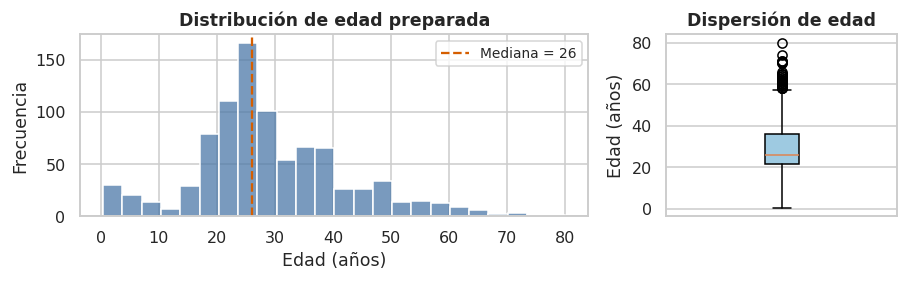

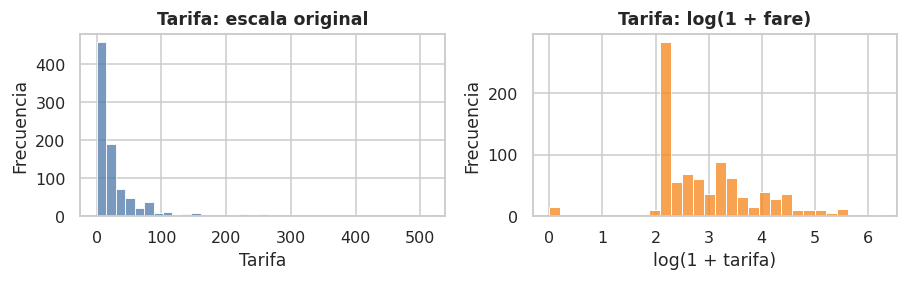

**Afirmación:** fare es asimétrica a la derecha. **Evidencia:** mediana 14,45, media 32,20 e IQR 23,09; el histograma muestra una cola extensa. **Razonamiento:** las tarifas altas desplazan la media; mediana e IQR describen mejor el centro sin descartar extremos.

**Afirmación:** la preparación concentra la edad y reduce su dispersión. **Evidencia:** en 714 edades observadas, mediana 28,0 y desviación estándar 14,53; en 891 edades preparadas, mediana 26,0, IQR 14,5 y desviación 13,30. **Razonamiento:** imputar medianas concentra casos alrededor de valores de grupo; la forma final incluye ese efecto metodológico.

**Afirmación:** la composición del conjunto es desigual. **Evidencia:** 577 hombres (64,8%), 491 pasajeros de tercera (55,1%) y 537 sin familiares registrados; family_size tiene mediana 1 y máximo 11. **Razonamiento:** las tasas por grupo deben leerse con sus denominadores, no solo con conteos absolutos.

In [6]:
def summ(series):
    s = series.dropna().astype(float)
    return pd.Series({'n':len(s), 'media':s.mean(), 'mediana':s.median(), 'std':s.std(),
        'q1':s.quantile(.25), 'q3':s.quantile(.75), 'IQR':s.quantile(.75)-s.quantile(.25),
        'min':s.min(), 'max':s.max()})
desc = pd.DataFrame({c:summ(prepared[c]) for c in ['age','age_clean','fare','family_size']}).T
frequencies = pd.concat([prepared[c].value_counts(sort=False).rename_axis('categoria').reset_index(name='n').assign(variable=c)
                         for c in ['survived','sex','class','family_group','age_group']], ignore_index=True)
frequencies['pct'] = frequencies.n / len(prepared) * 100
display(desc.round(3))
display(frequencies.round(2))
desc.to_csv(OUTPUTS_DIR / 'descriptivos_numericos.csv')
frequencies.to_csv(OUTPUTS_DIR / 'frecuencias.csv', index=False)
fig, axs = plt.subplots(1,2,figsize=(8.4,2.7),gridspec_kw={'width_ratios':[2.2,1]})
sns.histplot(prepared.age_clean,bins=24,color='#4C78A8',ax=axs[0])
axs[0].axvline(prepared.age_clean.median(),ls='--',color='#D55E00',label=f'Mediana = {prepared.age_clean.median():.0f}')
axs[0].set(title='Distribución de edad preparada',xlabel='Edad (años)',ylabel='Frecuencia')
axs[0].legend(fontsize=9)
axs[1].boxplot(prepared.age_clean, orientation='vertical', patch_artist=True, boxprops={'facecolor':'#9ECAE1'})
axs[1].set_xticks([])
axs[1].set(title='Dispersión de edad',ylabel='Edad (años)')
savefig(fig,'02_univariado_age.png')
fig, axs = plt.subplots(1,2,figsize=(8.4,2.7))
sns.histplot(prepared.fare,bins=35,color='#4C78A8',ax=axs[0])
axs[0].set(title='Tarifa: escala original',xlabel='Tarifa',ylabel='Frecuencia')
sns.histplot(prepared.fare_log1p,bins=30,color='#F58518',ax=axs[1])
axs[1].set(title='Tarifa: log(1 + fare)',xlabel='log(1 + tarifa)',ylabel='Frecuencia')
savefig(fig,'03_univariado_fare.png')
narrate('univariado', f"**Afirmación:** fare es asimétrica a la derecha. **Evidencia:** mediana {es(desc.loc['fare','mediana'],2)}, "
        f"media {es(desc.loc['fare','media'],2)} e IQR {es(desc.loc['fare','IQR'],2)}; el histograma muestra una cola extensa. "
        "**Razonamiento:** las tarifas altas desplazan la media; mediana e IQR describen mejor el centro sin descartar extremos.")
narrate('edad', f"**Afirmación:** la preparación concentra la edad y reduce su dispersión. **Evidencia:** en "
        f"{int(desc.loc['age','n'])} edades observadas, mediana {es(desc.loc['age','mediana'])} y desviación estándar "
        f"{es(desc.loc['age','std'],2)}; en {len(prepared)} edades preparadas, mediana {es(desc.loc['age_clean','mediana'])}, "
        f"IQR {es(desc.loc['age_clean','IQR'])} y desviación {es(desc.loc['age_clean','std'],2)}. "
        "**Razonamiento:** imputar medianas concentra casos alrededor de valores de grupo; la forma final incluye ese efecto metodológico.")
narrate('composicion', f"**Afirmación:** la composición del conjunto es desigual. **Evidencia:** "
        f"{int(prepared.sex.eq('male').sum())} hombres ({es(prepared.sex.eq('male').mean()*100)}%), "
        f"{int(prepared.pclass.eq(3).sum())} pasajeros de tercera ({es(prepared.pclass.eq(3).mean()*100)}%) "
        f"y {int(prepared.family_size.eq(1).sum())} sin familiares registrados; family_size tiene mediana "
        f"{es(desc.loc['family_size','mediana'],0)} y máximo {es(desc.loc['family_size','max'],0)}. "
        "**Razonamiento:** las tasas por grupo deben leerse con sus denominadores, no solo con conteos absolutos.")

## VIII. Análisis bivariado
Se comparan supervivencia por sexo, clase y composición familiar con tasas y tamaños de grupo; el cruce sexo × clase permite comprobar si las diferencias persisten dentro de estratos. Los boxplots de edad/tarifa se acompañan de medianas e IQR. No se calculan ni interpretan efectos causales.

,n,sobrevivientes,tasa,tasa_pct
sex,,,,
female,314,233,0.74,74.20
male,577,109,0.19,18.89


,n,sobrevivientes,tasa,tasa_pct
class,,,,
First,216,136,0.63,62.96
Second,184,87,0.47,47.28
Third,491,119,0.24,24.24


,n,sobrevivientes,tasa,tasa_pct
family_group,,,,
Solo,537,163,0.30,30.35
Pequeña (2-4),292,169,0.58,57.88
Grande (5+),62,10,0.16,16.13


class,First,Second,Third
sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54


n   media  mediana     std      q1    q3     IQR  \
variable  survived                                                         
age_clean 0         549.0  29.738     25.0  12.818  22.000  37.0  15.000   
          1         342.0  28.109     27.0  14.011  21.000  36.0  15.000   
fare      0         549.0  22.118     10.5  31.388   7.854  26.0  18.146   
          1         342.0  48.395     26.0  66.597  12.475  57.0  44.525   

                     min      max  
variable  survived                 
age_clean 0         1.00   74.000  
          1         0.42   80.000  
fare      0         0.00  263.000  
          1         0.00  512.329

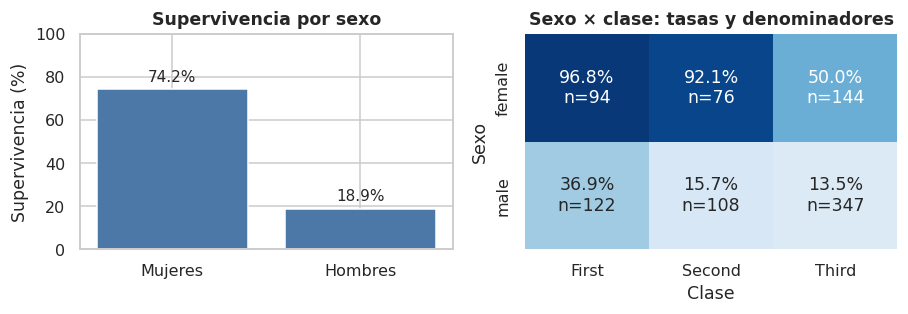

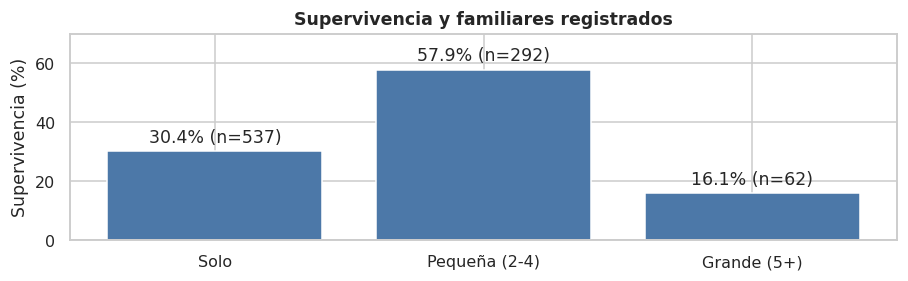

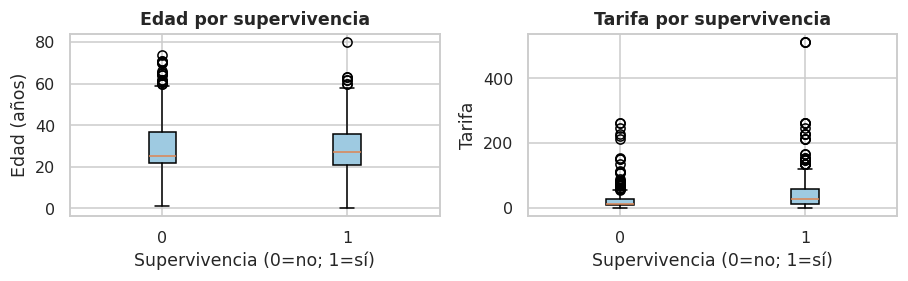

**Afirmación:** la supervivencia difiere por sexo y clase. **Evidencia:** 74,2% en mujeres y 18,9% en hombres; 63,0%, 47,3% y 24,2% en primera, segunda y tercera. **Razonamiento:** las diferencias por sexo persisten dentro de cada clase, lo que respalda una asociación descriptiva, sin controlar todos los factores ni demostrar causalidad.

**Afirmación:** la asociación familiar no es monótona. **Evidencia:** 57,9% en grupos pequeños (n=292), 30,4% en solitarios (n=537) y 16,1% en grupos grandes (n=62). **Razonamiento:** el máximo intermedio impide afirmar que más familiares se asocien siempre con mayor supervivencia.

**Afirmación:** los sobrevivientes presentan mayor tarifa central, pero edades centrales similares. **Evidencia:** mediana de tarifa 26,00 frente a 10,50 en no sobrevivientes; mediana de edad preparada 27,0 frente a 25,0 años. **Razonamiento:** los boxplots muestran solapamiento; estas diferencias no separan individualmente a los pasajeros ni prueban un efecto de la tarifa. La edad preparada incorpora imputación.

In [7]:
def rates(col):
    tab = prepared.groupby(col, observed=True).survived.agg(n='count',sobrevivientes='sum',tasa='mean')
    tab['tasa_pct'] = tab.tasa*100
    return tab
sex = rates('sex')
cl = rates('class')
fam = rates('family_group')
sc = prepared.pivot_table(index='sex', columns='class', values='survived', aggfunc='mean', observed=True)*100
sc_n = prepared.pivot_table(index='sex', columns='class', values='survived', aggfunc='size', observed=True)
for name, table in [('sexo',sex),('clase',cl),('grupo_familiar',fam),('sexo_clase',sc)]:
    display(table.round(2))
    table.to_csv(OUTPUTS_DIR / f'supervivencia_por_{name}.csv')
sc_n.to_csv(OUTPUTS_DIR / 'denominadores_sexo_clase.csv')
biv = pd.concat({c:prepared.groupby('survived')[c].apply(summ).unstack() for c in ['age_clean','fare']},names=['variable','survived'])
display(biv.round(3))
biv.to_csv(OUTPUTS_DIR / 'descriptivos_por_supervivencia.csv')
fig, axs = plt.subplots(1,2,figsize=(8.4,3.0))
axs[0].bar(['Mujeres','Hombres'],sex.loc[['female','male'],'tasa_pct'],color='#4C78A8')
axs[0].set(ylim=(0,100),ylabel='Supervivencia (%)',title='Supervivencia por sexo')
axs[0].bar_label(axs[0].containers[0],fmt='%.1f%%',padding=3,fontsize=10)
labels = np.array([[f'{sc.loc[s,c]:.1f}%\nn={sc_n.loc[s,c]}' for c in sc.columns] for s in sc.index])
sns.heatmap(sc,annot=labels,fmt='',cmap='Blues',vmin=0,vmax=100,cbar=False,ax=axs[1])
axs[1].set(title='Sexo × clase: tasas y denominadores',xlabel='Clase',ylabel='Sexo')
savefig(fig,'04_bivariado_sexo_clase.png')
fig, ax = plt.subplots(figsize=(8.4,2.7))
ax.bar(fam.index.astype(str),fam.tasa_pct,color='#4C78A8')
ax.set(ylim=(0,70),ylabel='Supervivencia (%)',title='Supervivencia y familiares registrados')
ax.bar_label(ax.containers[0],labels=[f'{t:.1f}% (n={int(n)})' for t,n in zip(fam.tasa_pct,fam.n)],padding=3)
savefig(fig,'05_bivariado_familia.png')
fig, axs = plt.subplots(1,2,figsize=(8.4,2.7))
for ax,col,title in zip(axs,['age_clean','fare'],['Edad por supervivencia','Tarifa por supervivencia']):
    ax.boxplot([prepared.loc[prepared.survived.eq(v),col] for v in [0,1]], tick_labels=['0','1'], orientation='vertical', patch_artist=True, boxprops={'facecolor':'#9ECAE1'})
    ax.set(title=title,xlabel='Supervivencia (0=no; 1=sí)',ylabel='Edad (años)' if col=='age_clean' else 'Tarifa')
savefig(fig,'06_bivariado_edad_fare.png')
narrate('sexo_clase', f"**Afirmación:** la supervivencia difiere por sexo y clase. **Evidencia:** "
        f"{es(sex.loc['female','tasa_pct'])}% en mujeres y {es(sex.loc['male','tasa_pct'])}% en hombres; "
        f"{es(cl.loc['First','tasa_pct'])}%, {es(cl.loc['Second','tasa_pct'])}% y {es(cl.loc['Third','tasa_pct'])}% "
        "en primera, segunda y tercera. **Razonamiento:** las diferencias por sexo persisten dentro de cada clase, "
        "lo que respalda una asociación descriptiva, sin controlar todos los factores ni demostrar causalidad.")
narrate('familia', f"**Afirmación:** la asociación familiar no es monótona. **Evidencia:** "
        f"{es(fam.loc['Pequeña (2-4)','tasa_pct'])}% en grupos pequeños (n={int(fam.loc['Pequeña (2-4)','n'])}), "
        f"{es(fam.loc['Solo','tasa_pct'])}% en solitarios (n={int(fam.loc['Solo','n'])}) y "
        f"{es(fam.loc['Grande (5+)','tasa_pct'])}% en grupos grandes (n={int(fam.loc['Grande (5+)','n'])}). "
        "**Razonamiento:** el máximo intermedio impide afirmar que más familiares se asocien siempre con mayor supervivencia.")
narrate('edad_tarifa', f"**Afirmación:** los sobrevivientes presentan mayor tarifa central, pero edades centrales similares. "
        f"**Evidencia:** mediana de tarifa {es(biv.loc[('fare',1),'mediana'],2)} frente a "
        f"{es(biv.loc[('fare',0),'mediana'],2)} en no sobrevivientes; mediana de edad preparada "
        f"{es(biv.loc[('age_clean',1),'mediana'])} frente a {es(biv.loc[('age_clean',0),'mediana'])} años. "
        "**Razonamiento:** los boxplots muestran solapamiento; estas diferencias no separan individualmente a los pasajeros "
        "ni prueban un efecto de la tarifa. La edad preparada incorpora imputación.")

## IX. Patrones, anomalías y hallazgos iniciales
Se identifican extremos mediante 1,5 × IQR y se contrastan con rangos, clases y contexto. Las tarifas cero requieren revisión, pero no se consideran errores demostrados. Los umbrales de edad dependen de la imputación; se muestran también los calculados con edad observada. El boxplot por clase usa escala `symlog`, lineal cerca de cero y logarítmica fuera de ese tramo; las distancias visuales no son diferencias monetarias uniformes.

,n_observados,q1,q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers,min,max
variable,,,,,,,,,,
age,714,20.125,38.0,17.875,-6.688,64.812,11,1.541,0.42,80.000
age_clean,891,21.500,36.0,14.500,-0.250,57.750,33,3.704,0.42,80.000
fare,891,7.910,31.0,23.090,-26.724,65.634,116,13.019,0.00,512.329


,row_id,pclass,sex,age,fare,survived
179,180,3,male,36.0,0.0,0
263,264,1,male,40.0,0.0,0
271,272,3,male,25.0,0.0,1
277,278,2,male,NaN,0.0,0
302,303,3,male,19.0,0.0,0
413,414,2,male,NaN,0.0,0
466,467,2,male,NaN,0.0,0
481,482,2,male,NaN,0.0,0
597,598,3,male,49.0,0.0,0
633,634,1,male,NaN,0.0,0


,row_id,pclass,sex,fare,survived,family_size
258,259,1,female,512.3292,1,1
737,738,1,male,512.3292,1,1
679,680,1,male,512.3292,1,2
27,28,1,male,263.0000,0,6
341,342,1,female,263.0000,1,6
438,439,1,male,263.0000,0,6
88,89,1,female,263.0000,1,6
311,312,1,female,262.3750,1,5
742,743,1,female,262.3750,1,5
299,300,1,female,247.5208,1,2


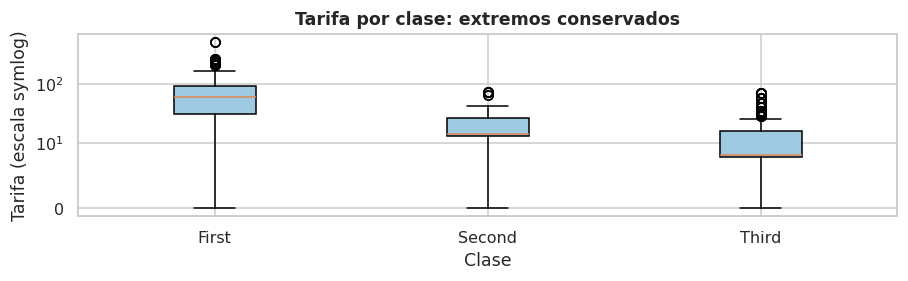

**Afirmación:** los extremos son plausibles, sin evidencia suficiente para excluirlos. **Evidencia:** 1,5 × IQR detecta 116 tarifas (13,0%) y 33 edades preparadas (3,7%); hay 15 tarifas cero. **Razonamiento:** los valores altos son compatibles con clases de mayor precio; un extremo estadístico no prueba error. Las tarifas cero quedan documentadas para verificar, sin atribuirles una causa.

Con edad observada se detectan 11 extremos entre 714 casos; con edad preparada, 33 entre 891. El límite superior pasa de 64,81 a 57,75 años. Por tanto, el mayor conteo no implica nuevos errores: cambia la distribución de referencia al imputar.

In [8]:
def outlier_summary(col):
    s = prepared[col].dropna()
    q1,q3 = s.quantile([.25,.75])
    iqr = q3-q1
    low,high = q1-1.5*iqr,q3+1.5*iqr
    mask = prepared[col].lt(low) | prepared[col].gt(high)
    return {'variable':col,'n_observados':len(s),'q1':q1,'q3':q3,'IQR':iqr,
            'lim_inf':low,'lim_sup':high,'n_outliers':int(mask.sum()),
            'pct_outliers':100*mask.sum()/len(s),'min':s.min(),'max':s.max()},mask
out_rows=[]
for c in ['age','age_clean','fare']:
    item,mask = outlier_summary(c)
    out_rows.append(item)
    if c=='fare': fare_mask=mask
out = pd.DataFrame(out_rows).set_index('variable')
display(out.round(3))
zeros = prepared.loc[prepared.fare.eq(0),['row_id','pclass','sex','age','fare','survived']]
display(zeros)
display(prepared.loc[fare_mask,['row_id','pclass','sex','fare','survived','family_size']].sort_values('fare',ascending=False).head(12))
out.to_csv(OUTPUTS_DIR / 'resumen_outliers_iqr.csv')
zeros.to_csv(OUTPUTS_DIR / 'casos_tarifa_cero.csv',index=False)
fig,ax=plt.subplots(figsize=(8.4,2.7))
ax.boxplot([prepared.loc[prepared['class'].eq(c),'fare'] for c in ['First','Second','Third']], tick_labels=['First','Second','Third'], orientation='vertical', patch_artist=True, boxprops={'facecolor':'#9ECAE1'})
ax.set_yscale('symlog',linthresh=10)
ax.set(title='Tarifa por clase: extremos conservados',xlabel='Clase',ylabel='Tarifa (escala symlog)')
savefig(fig,'07_outliers_fare_clase.png')
narrate('outliers', f"**Afirmación:** los extremos son plausibles, sin evidencia suficiente para excluirlos. "
        f"**Evidencia:** 1,5 × IQR detecta {int(out.loc['fare','n_outliers'])} tarifas ({es(out.loc['fare','pct_outliers'])}%) "
        f"y {int(out.loc['age_clean','n_outliers'])} edades preparadas ({es(out.loc['age_clean','pct_outliers'])}%); "
        f"hay {len(zeros)} tarifas cero. **Razonamiento:** los valores altos son compatibles con clases de mayor precio; "
        "un extremo estadístico no prueba error. Las tarifas cero quedan documentadas para verificar, sin atribuirles una causa.")
narrate('sensibilidad', f"Con edad observada se detectan {int(out.loc['age','n_outliers'])} extremos entre "
        f"{int(out.loc['age','n_observados'])} casos; con edad preparada, {int(out.loc['age_clean','n_outliers'])} entre "
        f"{len(prepared)}. El límite superior pasa de {es(out.loc['age','lim_sup'],2)} a "
        f"{es(out.loc['age_clean','lim_sup'],2)} años. Por tanto, el mayor conteo no implica nuevos errores: "
        "cambia la distribución de referencia al imputar.")

## X. Supuestos, límites y cierre del avance
La mediana por sexo × clase supone que la edad típica del subgrupo es una aproximación útil para sus ausencias; no demuestra que el mecanismo de falta sea aleatorio. `Unknown` conserva información de ausencia, no reconstruye cubierta. La moda no recupera los puertos reales. La igualdad de perfiles sin identificador no prueba duplicación; `row_id` depende del orden de esta entrada.

El conjunto es histórico, observacional y un subconjunto de pasajeros; no permite generalización automática a toda la población a bordo ni inferencia causal. `family_size` solo cubre parentescos registrados y `fare` puede reflejar tickets compartidos que este esquema no permite resolver. Las tasas usan grupos de tamaños distintos. `alive` reproduce el resultado `survived`; debe excluirse de futuros predictores. `class/pclass`, `who`, `adult_male` y otras derivadas requieren selección para evitar redundancia. En modelos posteriores se debe ajustar la imputación solo sobre entrenamiento para evitar fuga entre particiones.

La sensibilidad descriptiva de edad se examinó en VII y IX; quedan pendientes análisis de mecanismos de faltantes, estrategias alternativas e interacciones multivariadas. No se presentan pruebas de significación, estimaciones causales ni un modelo predictivo.

## XI. Cierre del avance
Se preservaron 891 registros, las variables originales y el historial de preparación, con validación de claves y consistencia. Los hallazgos respaldados son diferencias descriptivas por sexo y clase, asociación familiar no monótona, mayor tarifa central entre sobrevivientes, asimetría de tarifa y extremos que ameritan revisión contextual.

**Continuidad:** contrastar estrategias de imputación y mecanismos de ausencia, estudiar interacciones con denominadores explícitos y revisar tarifas cero contra una fuente con identificador antes de corregir o excluir. Cualquier modelamiento deberá separar entrenamiento y evaluación y retirar variables que revelen el resultado.

**Referencias**

Paraíso, S. (2026a). *Pandas limpieza + joins* [Apunte]. Universidad Andrés Bello.

Paraíso, S. (2026b). *Reglas de calidad* [Apunte]. Universidad Andrés Bello.

Universidad Andrés Bello. (2026). *Evaluación Sumativa 2: Avance del proyecto Fases 2 y 3* [Instrucciones y rúbrica].

Waskom, M. (s. f.). *titanic.csv* [Conjunto de datos]. GitHub. https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv

### Auditoría final y salidas
Los controles siguientes verifican condiciones calculadas. No constituyen una calificación académica automática.

In [9]:
checks_final = {
    '891_filas': len(prepared)==len(original)==891,
    '15_originales_conservadas': set(expected).issubset(prepared.columns),
    'sin_cambios_entrada': hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()==sha,
    'reglas_originales': bool(check_table.cumple.all()),
    'reglas_posteriores': bool(all(post_checks.values())),
    'merge_sin_perdidas': len(merged)==len(core)==len(context) and key_audit._merge.eq('both').all(),
    '7_figuras_de_esta_ejecucion': len(figures_created)==7 and all((FIGURES_DIR/f).is_file() for f in figures_created),
    'exportacion_preparada': reloaded.shape==prepared.shape,
    'banderas_missing': int(prepared.age_imputed.sum())==int(original.age.isna().sum())
}
assert all(checks_final.values()), checks_final
display(pd.Series(checks_final,name='cumple').to_frame())
manifest = {'input_file':str(DATA_PATH.relative_to(PROJECT_ROOT)), 'input_sha256':sha,
            'rows':len(prepared), 'columns_prepared':prepared.shape[1],
            'versions':{'python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,
                        'matplotlib':matplotlib.__version__,'seaborn':sns.__version__},
            'figures':figures_created, 'checks':{k:bool(v) for k,v in checks_final.items()}}
(OUTPUTS_DIR/'manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
(OUTPUTS_DIR/'interpretaciones.json').write_text(json.dumps(interpretations,indent=2,ensure_ascii=False),encoding='utf-8')
print('Proceso finalizado; controles técnicos aprobados. La evaluación académica corresponde al docente.')

Proceso finalizado; controles técnicos aprobados. La evaluación académica corresponde al docente.


,cumple
891_filas,True
15_originales_conservadas,True
sin_cambios_entrada,True
reglas_originales,True
reglas_posteriores,True
merge_sin_perdidas,True
7_figuras_de_esta_ejecucion,True
exportacion_preparada,True
banderas_missing,True
